# Academic Paper Recommendation

## 1. Introduction

This study investigates academic paper recommendation using a fixed dataset pipeline generated from arXiv and OpenAlex sources. The `academic-paper-recommendation.ipynb` notebook focuses on downstream implementation and evaluation: data loading, exploration, cleaning, preprocessing/indexing, embedding, evaluation with standard IR metrics, and embedding geometry analysis.

### Objectives

1. Define and justify a methodology for building a domain-specific AI/ML corpus from arXiv.
2. Construct and document an enrichment workflow using OpenAlex metadata and citation signals.
3. Analyse data quality and corpus characteristics to identify strengths, biases, and risks to validity.
4. Build query and qrels resources suitable for reproducible offline evaluation.
5. Implement and evaluate recommendation approaches using standard IR metrics and comparative analysis.
6. Provide critical appraisal of outcomes, limitations, and actionable directions for further work.

In [1]:
# =========================================================
# Import required libraries
# =========================================================
# %pip install matplotlib pandas torch torchvision scikit-learn sentence-transformers umap-learn
import json
import os
import time
import math
import gc
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

from sentence_transformers import SentenceTransformer

try:
    import umap
except ImportError:
    umap = None

/Users/ayomideolakulehin/mambaforge/envs/msc-paper-recommendation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================================
# Configuration
# =========================================================

DATA_DIR = "data"
OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")

PAPERS_PATH = os.path.join(DATA_DIR, "openalex_enriched.jsonl")
DATASET_METADATA_PATH = os.path.join(DATA_DIR, "dataset_metadata.json")
QUERIES_PATH = os.path.join(DATA_DIR, "queries.jsonl")
QRELS_PATH = os.path.join(DATA_DIR, "qrels.jsonl")

SBERT_MODEL_NAME = "all-MiniLM-L6-v2"
TOP_K_VALUES = [5, 10, 20]
RANDOM_SEED = 70

HYBRID_ALPHA = 0.5
TWO_STAGE_CANDIDATE_SIZE = 100

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

## 2. Functions

Functions used re-used in this experiment are added to this section

### Utilities

In [21]:
def load_jsonl(path: str) -> List[Dict]:
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def load_json(path: str) -> Dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_json(data: Dict, path: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


def save_dataframe(df: pd.DataFrame, path: str) -> None:
    df.to_csv(path, index=False)


def normalise_whitespace(text: str) -> str:
    return " ".join(text.split()).strip()

### Evaluation Metrics Functions

In [22]:
def precision_at_k(ranked_ids: List[str], relevant_ids: set, k: int) -> float:
    top_k = ranked_ids[:k]
    if not top_k:
        return 0.0
    hits = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return hits / k


def recall_at_k(ranked_ids: List[str], relevant_ids: set, k: int) -> float:
    top_k = ranked_ids[:k]
    if not relevant_ids:
        return 0.0
    hits = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return hits / len(relevant_ids)


def reciprocal_rank(ranked_ids: List[str], relevant_ids: set) -> float:
    for i, doc_id in enumerate(ranked_ids, start=1):
        if doc_id in relevant_ids:
            return 1.0 / i
    return 0.0


def dcg_at_k(ranked_ids: List[str], relevant_ids: set, k: int) -> float:
    dcg = 0.0
    for i, doc_id in enumerate(ranked_ids[:k], start=1):
        rel = 1 if doc_id in relevant_ids else 0
        if rel > 0:
            dcg += rel / math.log2(i + 1)
    return dcg


def ndcg_at_k(ranked_ids: List[str], relevant_ids: set, k: int) -> float:
    dcg = dcg_at_k(ranked_ids, relevant_ids, k)
    ideal_count = min(len(relevant_ids), k)
    if ideal_count == 0:
        return 0.0
    ideal_ids = [1] * ideal_count
    idcg = sum(rel / math.log2(i + 1) for i, rel in enumerate(ideal_ids, start=1))
    return dcg / idcg if idcg > 0 else 0.0

### Experiment Runner

In [37]:
def evaluate_system(
    system_name: str,
    queries: List[Dict],
    qrels_map: Dict[str, List[str]],
    index: CorpusIndex,
    rank_fn
) -> pd.DataFrame:

    rows = []

    for q in queries:
        query_id = q["query_id"]
        query_text = q["query_text"]
        relevant_ids = set(qrels_map.get(query_id, []))

        start = time.perf_counter()
        ranked = rank_fn(query_text, index)
        latency = time.perf_counter() - start

        ranked_ids = [doc_id for doc_id, _ in ranked]

        row = {
            "system": system_name,
            "query_id": query_id,
            "latency_seconds": latency,
            "mrr": reciprocal_rank(ranked_ids, relevant_ids),
        }

        for k in TOP_K_VALUES:
            row[f"precision@{k}"] = precision_at_k(ranked_ids, relevant_ids, k)
            row[f"recall@{k}"] = recall_at_k(ranked_ids, relevant_ids, k)
            row[f"ndcg@{k}"] = ndcg_at_k(ranked_ids, relevant_ids, k)

        rows.append(row)

    return pd.DataFrame(rows)

### Retrieval Functions

In [40]:
def rank_tfidf(query_text: str, index: CorpusIndex, top_n: int = 1000) -> List[Tuple[str, float]]:
    q_vec = index.tfidf_vectorizer.transform([query_text])
    scores = cosine_similarity(q_vec, index.tfidf_matrix).flatten()

    top_idx = np.argsort(scores)[::-1][:top_n]
    return [(index.paper_ids[i], float(scores[i])) for i in top_idx]


def rank_dense(query_text: str, index: CorpusIndex, top_n: int = 1000) -> List[Tuple[str, float]]:
    q_vec = index.dense_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    scores = np.dot(index.dense_matrix, q_vec[0])

    top_idx = np.argsort(scores)[::-1][:top_n]
    return [(index.paper_ids[i], float(scores[i])) for i in top_idx]


def rank_hybrid(query_text: str, index: CorpusIndex, alpha: float = HYBRID_ALPHA, top_n: int = 1000) -> List[Tuple[str, float]]:
    tfidf_ranked = rank_tfidf(query_text, index, top_n=len(index.paper_ids))
    dense_ranked = rank_dense(query_text, index, top_n=len(index.paper_ids))

    tfidf_scores = {doc_id: score for doc_id, score in tfidf_ranked}
    dense_scores = {doc_id: score for doc_id, score in dense_ranked}

    all_doc_ids = index.paper_ids
    combined = []

    for doc_id in all_doc_ids:
        tfidf_score = tfidf_scores.get(doc_id, 0.0)
        dense_score = dense_scores.get(doc_id, 0.0)
        score = alpha * tfidf_score + (1 - alpha) * dense_score
        combined.append((doc_id, score))

    combined.sort(key=lambda x: x[1], reverse=True)
    return combined[:top_n]


def rank_two_stage(query_text: str, index: CorpusIndex, candidate_size: int = TWO_STAGE_CANDIDATE_SIZE, top_n: int = 1000) -> List[Tuple[str, float]]:
    first_stage = rank_tfidf(query_text, index, top_n=candidate_size)
    candidate_ids = [doc_id for doc_id, _ in first_stage]

    q_vec = index.dense_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )[0]

    id_to_pos = {pid: i for i, pid in enumerate(index.paper_ids)}
    reranked = []

    for doc_id in candidate_ids:
        pos = id_to_pos[doc_id]
        score = float(np.dot(index.dense_matrix[pos], q_vec))
        reranked.append((doc_id, score))

    reranked.sort(key=lambda x: x[1], reverse=True)
    return reranked[:top_n]

### Results and Analysis Functions

In [54]:
def summarise_results(df: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [c for c in df.columns if c not in ["system", "query_id"]]
    summary = df.groupby("system")[metric_cols].mean().reset_index()
    return summary

def plot_dense_embedding_geometry(index: CorpusIndex, papers: List[Dict], sample_size: int = 1000) -> None:
    if len(papers) > sample_size:
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(len(papers), size=sample_size, replace=False)
        dense = index.dense_matrix[idx]
        cats = [papers[i]["primary_category"] for i in idx]
    else:
        dense = index.dense_matrix
        cats = [p["primary_category"] for p in papers]

    # PCA
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    pca_result = pca.fit_transform(dense)

    plt.figure(figsize=(8, 6))
    for cat in sorted(set(cats)):
        mask = [c == cat for c in cats]
        plt.scatter(
            pca_result[mask, 0],
            pca_result[mask, 1],
            label=cat,
            alpha=0.6,
            s=10
        )
    plt.title("PCA of Dense Document Embeddings")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "pca_dense_embeddings.png"), dpi=300)
    plt.show()
    plt.close()

    # UMAP
    if umap is not None:
        reducer = umap.UMAP(n_components=2, random_state=RANDOM_SEED)
        umap_result = reducer.fit_transform(dense)

        plt.figure(figsize=(8, 6))
        for cat in sorted(set(cats)):
            mask = [c == cat for c in cats]
            plt.scatter(
                umap_result[mask, 0],
                umap_result[mask, 1],
                label=cat,
                alpha=0.6,
                s=10
            )
        plt.title("UMAP of Dense Document Embeddings")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, "umap_dense_embeddings.png"), dpi=300)
        plt.close()


## 3. Data Loading

In [23]:

print("Loading data...")
papers = load_jsonl(PAPERS_PATH)
queries = load_jsonl(QUERIES_PATH)
qrels = load_jsonl(QRELS_PATH)
dataset_metadata = load_json(DATASET_METADATA_PATH)
print("Data loaded successfully.")



Loading data...
Data loaded successfully.


## 4. Data Exploration

**Purpose:** This section validates the quality, structure, and suitability of the dataset before model development and evaluation. It provides evidence on corpus composition, enrichment reliability, citation signal characteristics, and potential risks (e.g., imbalance, sparsity, duplicates) so that later retrieval results can be interpreted critically and reproducibly.


### 4.1 Category Distribution

**Justification:** Category balance affects retrieval fairness and interpretation of model performance. This analysis shows whether one research area dominates the corpus.


Category distribution:


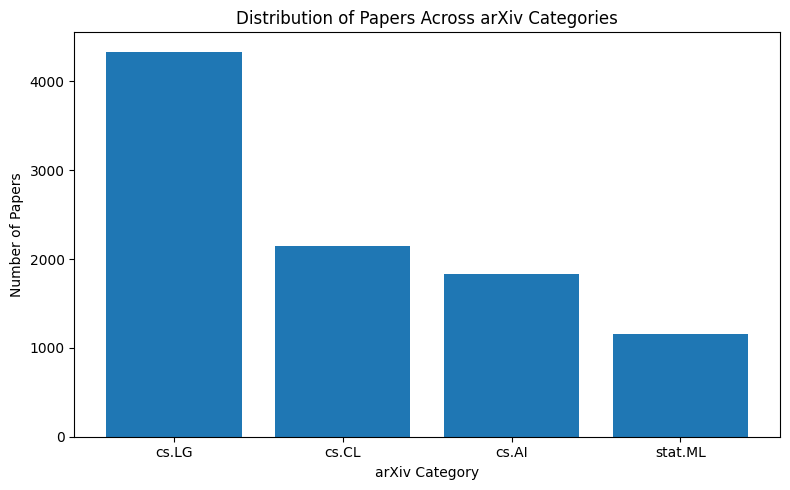

In [24]:
categories = [p["primary_category"] for p in papers]

# Category distribution
print("Category distribution:")
category_counts = dataset_metadata.get("category_counts", {})
plt.figure(figsize=(8, 5))
plt.bar(category_counts.keys(), category_counts.values())
plt.xlabel("arXiv Category")
plt.ylabel("Number of Papers")
plt.title("Distribution of Papers Across arXiv Categories")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "category_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.2 Abstract Length Distribution

**Justification:** Abstract length influences text representation quality and can bias embedding-based retrieval. This helps validate preprocessing and model input assumptions.

Abstract length distribution:


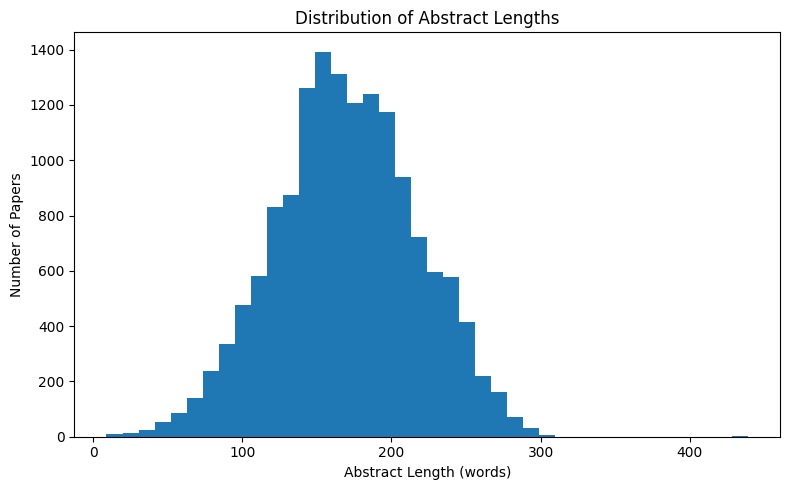

In [25]:
abstract_lengths = [len(p["abstract"].split()) for p in papers]

# Abstract length distribution
print("Abstract length distribution:")
plt.figure(figsize=(8, 5))
plt.hist(abstract_lengths, bins=40)
plt.xlabel("Abstract Length (words)")
plt.ylabel("Number of Papers")
plt.title("Distribution of Abstract Lengths")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "abstract_length_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.3 Corpus Summary Statistics

**Justification:** High-level corpus statistics provide a compact quality check and establish reproducible baseline characteristics for later experiments.

In [26]:

# Save corpus summary table
summary = pd.DataFrame([
    {"Statistic": "Corpus size", "Value": len(papers)},
    {"Statistic": "Average abstract length", "Value": round(np.mean(abstract_lengths), 2)},
    {"Statistic": "Median abstract length", "Value": round(np.median(abstract_lengths), 2)},
    {"Statistic": "Vocabulary proxy (unique categories)", "Value": len(set(categories))}
])
print("Corpus summary:")
print(summary)
save_dataframe(summary, os.path.join(TABLES_DIR, "corpus_summary.csv"))

Corpus summary:
                              Statistic     Value
0                           Corpus size  15000.00
1               Average abstract length    169.89
2                Median abstract length    169.00
3  Vocabulary proxy (unique categories)    119.00


### 4.4 Data Quality Audit

**Justification:** Missing and invalid values directly affect matching quality, retrieval performance, and reproducibility. Auditing key fields quantifies data reliability before modeling.

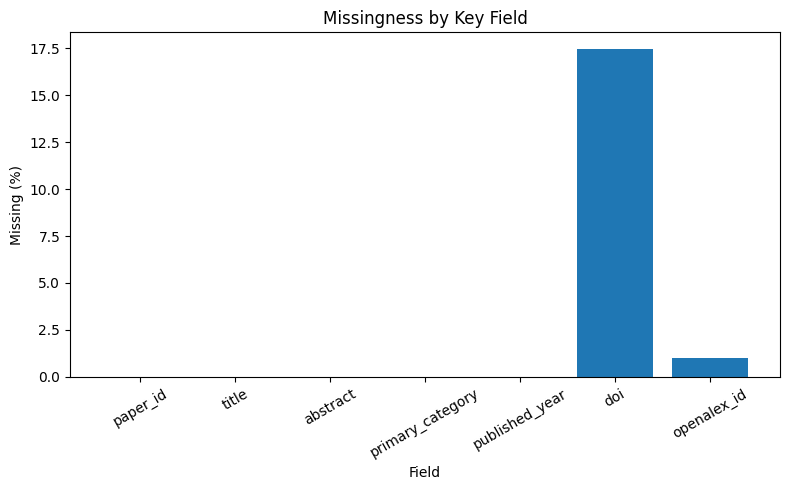

In [27]:
OPENALEX_META_PATH = os.path.join(DATA_DIR, "openalex_enrichment_metadata.json")

papers_df = pd.DataFrame(papers)
queries_df = pd.DataFrame(queries)
qrels_df = pd.DataFrame(qrels)

required_fields = ["paper_id", "title", "abstract", "primary_category", "published_year", "doi", "openalex_id"]
quality_rows = []

for field in required_fields:
    if field not in papers_df.columns:
        missing_count = len(papers_df)
    else:
        series = papers_df[field]
        if field in ["paper_id", "title", "abstract", "primary_category", "doi", "openalex_id"]:
            missing_count = int(series.isna().sum() + series.astype(str).str.strip().eq("").sum())
        else:
            missing_count = int(series.isna().sum())

    quality_rows.append({
        "field": field,
        "missing_count": missing_count,
        "missing_percent": round((missing_count / len(papers_df)) * 100, 2) if len(papers_df) else 0,
    })

quality_df = pd.DataFrame(quality_rows)

eligible_mask = (
    papers_df.get("paper_id", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
    & papers_df.get("title", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
    & papers_df.get("abstract", pd.Series([""] * len(papers_df))).astype(str).str.strip().ne("")
)

cleaning_summary_df = pd.DataFrame([
    {"metric": "raw_records", "value": int(len(papers_df))},
    {"metric": "records_after_cleaning_rules", "value": int(eligible_mask.sum())},
    {"metric": "dropped_by_cleaning_rules", "value": int((~eligible_mask).sum())},
    {
        "metric": "drop_rate_percent",
        "value": round((((~eligible_mask).sum() / len(papers_df)) * 100), 2) if len(papers_df) else 0,
    },
])

save_dataframe(quality_df, os.path.join(TABLES_DIR, "data_quality_summary.csv"))
save_dataframe(cleaning_summary_df, os.path.join(TABLES_DIR, "cleaning_summary.csv"))

plt.figure(figsize=(8, 5))
plt.bar(quality_df["field"], quality_df["missing_percent"])
plt.xlabel("Field")
plt.ylabel("Missing (%)")
plt.title("Missingness by Key Field")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "missingness_by_field.png"), dpi=300)
plt.show()
plt.close()

### 4.5 OpenAlex Enrichment Quality

**Justification:** Recommendation quality depends on enrichment coverage. This analysis evaluates match success, failure modes, and enrichment confidence.

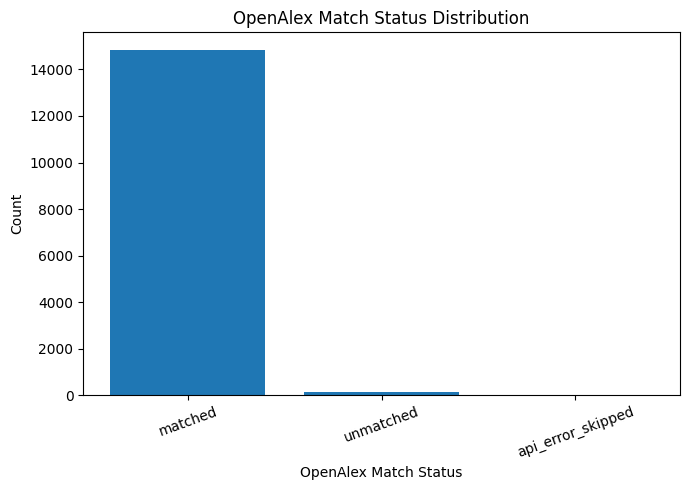

In [28]:
status_series = papers_df.get("openalex_match_status", pd.Series(["missing"] * len(papers_df)))
status_counts = status_series.fillna("missing").value_counts().sort_values(ascending=False)
status_df = pd.DataFrame({"openalex_match_status": status_counts.index, "count": status_counts.values})
save_dataframe(status_df, os.path.join(TABLES_DIR, "openalex_match_status_counts.csv"))

if os.path.exists(OPENALEX_META_PATH):
    openalex_meta = load_json(OPENALEX_META_PATH)
    enrichment_quality_df = pd.DataFrame([
        {"metric": "matched_by_doi", "value": openalex_meta.get("matched_by_doi", 0)},
        {"metric": "matched_by_title", "value": openalex_meta.get("matched_by_title", 0)},
        {"metric": "unmatched", "value": openalex_meta.get("unmatched", 0)},
        {"metric": "api_errors_skipped", "value": openalex_meta.get("api_errors_skipped", 0)},
        {"metric": "match_rate", "value": openalex_meta.get("match_rate", 0)},
    ])
    save_dataframe(enrichment_quality_df, os.path.join(TABLES_DIR, "openalex_enrichment_quality.csv"))

plt.figure(figsize=(7, 5))
plt.bar(status_df["openalex_match_status"], status_df["count"])
plt.xlabel("OpenAlex Match Status")
plt.ylabel("Count")
plt.title("OpenAlex Match Status Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "openalex_match_status_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.6 Citation Structure Analysis

**Justification:** Citation-based signals support relevance modeling and query generation. Understanding citation distributions helps justify their use and limitations.

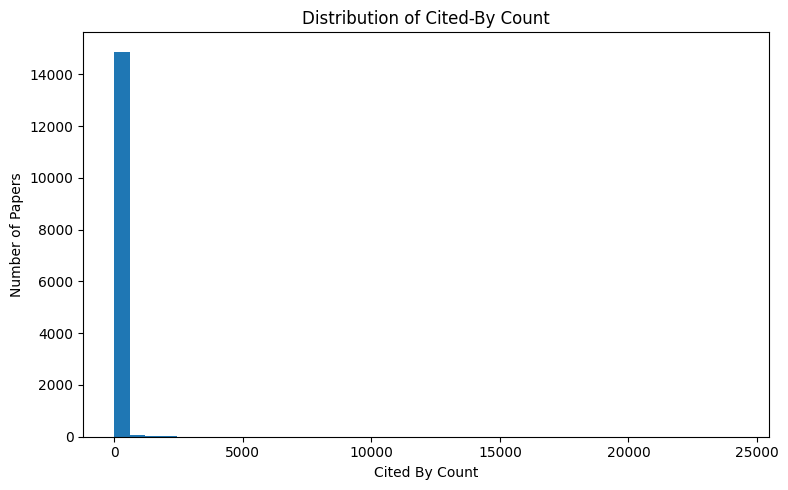

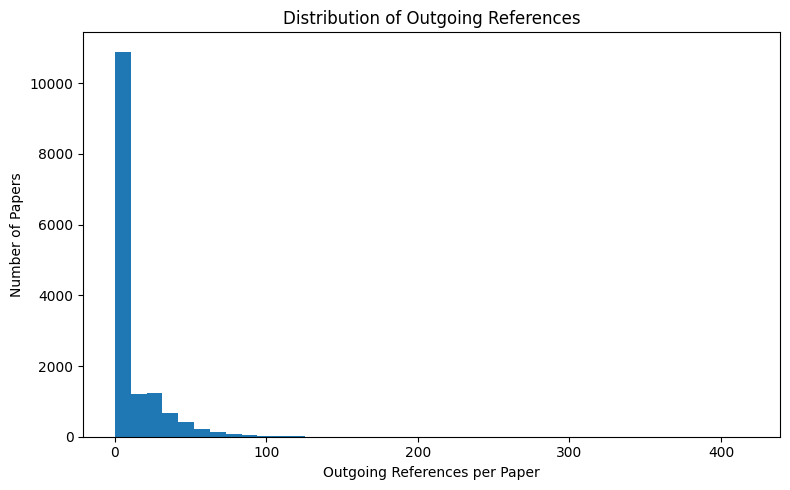

In [29]:
cited_by = pd.to_numeric(papers_df.get("cited_by_count", pd.Series([0] * len(papers_df))), errors="coerce").fillna(0)
outgoing_refs = papers_df.get("referenced_works", pd.Series([[]] * len(papers_df))).apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

citation_summary_df = pd.DataFrame([
    {"metric": "avg_cited_by_count", "value": round(float(cited_by.mean()), 2)},
    {"metric": "median_cited_by_count", "value": round(float(cited_by.median()), 2)},
    {"metric": "p90_cited_by_count", "value": round(float(np.percentile(cited_by, 90)), 2) if len(cited_by) else 0},
    {"metric": "avg_outgoing_references", "value": round(float(outgoing_refs.mean()), 2)},
    {"metric": "median_outgoing_references", "value": round(float(outgoing_refs.median()), 2)},
])
save_dataframe(citation_summary_df, os.path.join(TABLES_DIR, "citation_summary.csv"))

plt.figure(figsize=(8, 5))
plt.hist(cited_by, bins=40)
plt.xlabel("Cited By Count")
plt.ylabel("Number of Papers")
plt.title("Distribution of Cited-By Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "cited_by_count_distribution.png"), dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.hist(outgoing_refs, bins=40)
plt.xlabel("Outgoing References per Paper")
plt.ylabel("Number of Papers")
plt.title("Distribution of Outgoing References")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "outgoing_references_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.7 Query and Qrels Diagnostics

**Justification:** Retrieval evaluation quality depends on query relevance density. This section checks whether the benchmark is informative and not overly sparse.

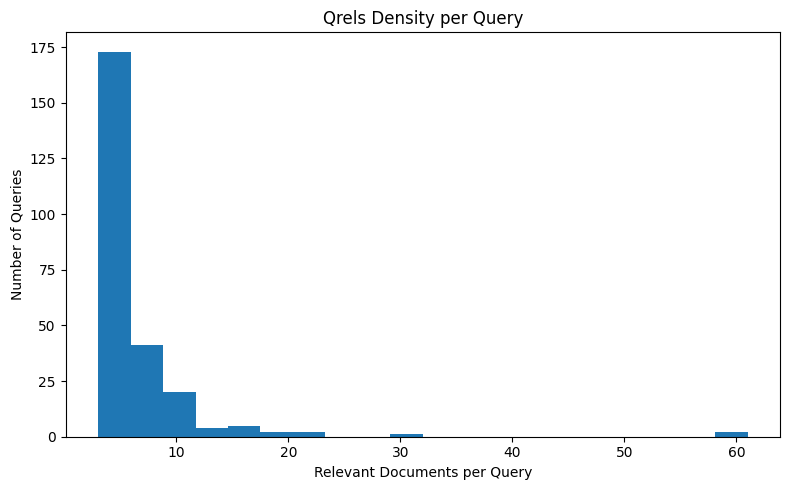

In [30]:
qrels_per_query = qrels_df.groupby("query_id")["doc_id"].nunique().sort_values(ascending=False)
qrels_summary_df = pd.DataFrame([
    {"metric": "num_queries", "value": int(queries_df["query_id"].nunique() if "query_id" in queries_df else 0)},
    {"metric": "num_qrels_pairs", "value": int(len(qrels_df))},
    {"metric": "avg_relevant_docs_per_query", "value": round(float(qrels_per_query.mean()), 2) if len(qrels_per_query) else 0},
    {"metric": "median_relevant_docs_per_query", "value": round(float(qrels_per_query.median()), 2) if len(qrels_per_query) else 0},
    {"metric": "queries_with_<=3_relevant_docs", "value": int((qrels_per_query <= 3).sum()) if len(qrels_per_query) else 0},
])
save_dataframe(qrels_summary_df, os.path.join(TABLES_DIR, "qrels_summary.csv"))

plt.figure(figsize=(8, 5))
plt.hist(qrels_per_query.values, bins=20)
plt.xlabel("Relevant Documents per Query")
plt.ylabel("Number of Queries")
plt.title("Qrels Density per Query")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "qrels_per_query_distribution.png"), dpi=300)
plt.show()
plt.close()

### 4.8 Class Imbalance and Duplicate Checks

**Justification:** Imbalance and duplicates can bias evaluation and inflate apparent performance. These checks support critical discussion of dataset threats to validity.

In [31]:
cat_counts = pd.Series(dataset_metadata.get("category_counts", {}), dtype="float64")
imbalance_ratio = round(float(cat_counts.max() / cat_counts.min()), 3) if len(cat_counts) and cat_counts.min() > 0 else np.nan

norm_titles = papers_df.get("title", pd.Series([""] * len(papers_df))).fillna("").astype(str).str.lower()
norm_titles = norm_titles.str.replace(r"\s+", " ", regex=True).str.strip()

doi_series = papers_df.get("doi", pd.Series([""] * len(papers_df))).fillna("").astype(str).str.lower().str.strip()
doi_series = doi_series.str.replace("https://doi.org/", "", regex=False)
doi_series = doi_series.str.replace("http://doi.org/", "", regex=False)
doi_series = doi_series.str.replace("doi.org/", "", regex=False)
non_empty_doi = doi_series[doi_series.ne("")]

imbalance_duplicate_df = pd.DataFrame([
    {"metric": "category_imbalance_ratio_max_over_min", "value": imbalance_ratio},
    {"metric": "duplicate_titles_exact_count", "value": int(norm_titles.duplicated().sum())},
    {"metric": "duplicate_doi_exact_count", "value": int(non_empty_doi.duplicated().sum())},
])
print("Imbalance and duplicates summary:")
print(imbalance_duplicate_df)
save_dataframe(imbalance_duplicate_df, os.path.join(TABLES_DIR, "imbalance_and_duplicates_summary.csv"))

print("Section 4 exploration outputs saved to outputs/figures and outputs/tables.")

Imbalance and duplicates summary:
                                  metric  value
0  category_imbalance_ratio_max_over_min   3.75
1           duplicate_titles_exact_count   4.00
2              duplicate_doi_exact_count   4.00
Section 4 exploration outputs saved to outputs/figures and outputs/tables.


## 5. Data Cleaning

In [32]:
cleaned_papers = []

for p in papers:
    title = normalise_whitespace(p.get("title", ""))
    abstract = normalise_whitespace(p.get("abstract", ""))
    primary_category = p.get("primary_category", "")
    paper_id = p.get("paper_id", "")

    if not paper_id or not title or not abstract:
        continue

    cleaned_papers.append({
        **p,
        "title": title,
        "abstract": abstract,
        "primary_category": primary_category,
        "text": f"{title} {abstract}".strip()
    })

## 6. Preprocessing

In [33]:
print("Building lookup structures...")
paper_map = {p["paper_id"]: p for p in cleaned_papers}
query_map = {q["query_id"]: q for q in queries}

qrels_map = defaultdict(list)
for r in qrels:
    qrels_map[r["query_id"]].append(r["doc_id"])

Building lookup structures...


In [34]:
print("Building corpus index...")

@dataclass
class CorpusIndex:
    paper_ids: List[str]
    texts: List[str]
    tfidf_vectorizer: TfidfVectorizer = None
    tfidf_matrix: np.ndarray = None
    dense_model: SentenceTransformer = None
    dense_matrix: np.ndarray = None


paper_ids = [p["paper_id"] for p in cleaned_papers]
texts = [p["text"] for p in cleaned_papers]

index = CorpusIndex(paper_ids=paper_ids, texts=texts)


Building corpus index...


In [35]:
# TF-IDF Indexing
def fit_tfidf(index: CorpusIndex) -> float:
    start = time.perf_counter()

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 1),
        norm="l2"
    )
    matrix = vectorizer.fit_transform(index.texts)

    elapsed = time.perf_counter() - start

    index.tfidf_vectorizer = vectorizer
    index.tfidf_matrix = matrix
    return elapsed

print("Fitting TF-IDF...")
tfidf_build_time = fit_tfidf(index)
print(f"TF-IDF indexing completed in {tfidf_build_time:.2f} seconds")

Fitting TF-IDF...
TF-IDF indexing completed in 0.96 seconds


In [36]:
# Dense Embeddings
def build_dense_embeddings(index: CorpusIndex) -> float:
    start = time.perf_counter()

    model = SentenceTransformer(SBERT_MODEL_NAME)
    dense_matrix = model.encode(
        index.texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    elapsed = time.perf_counter() - start

    index.dense_model = model
    index.dense_matrix = dense_matrix
    return elapsed

print("Encoding SBERT embeddings...")
dense_build_time = build_dense_embeddings(index)
print(f"SBERT embedding completed in {dense_build_time:.2f} seconds")

Encoding SBERT embeddings...


Batches: 100%|██████████| 235/235 [00:48<00:00,  4.84it/s]


SBERT embedding completed in 50.95 seconds


## 7. Evaluation

### 7.1 TF-IDF Evaluation

In [43]:
print("Evaluating TF-IDF...")
tfidf_results = evaluate_system(
    "TF-IDF",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_tfidf(qt, idx, top_n=1000)
)
print("TF-IDF evaluation results:")
print(tfidf_results)

Evaluating TF-IDF...
TF-IDF evaluation results:
     system query_id  latency_seconds       mrr  precision@5  recall@5  \
0    TF-IDF     Q001         0.012959  0.500000          0.4  0.500000   
1    TF-IDF     Q002         0.018192  0.500000          0.2  0.333333   
2    TF-IDF     Q003         0.010438  0.050000          0.0  0.000000   
3    TF-IDF     Q004         0.008354  0.033333          0.0  0.000000   
4    TF-IDF     Q005         0.007704  0.500000          0.2  0.062500   
..      ...      ...              ...       ...          ...       ...   
245  TF-IDF     Q246         0.007269  0.500000          0.2  0.125000   
246  TF-IDF     Q247         0.007211  0.142857          0.0  0.000000   
247  TF-IDF     Q248         0.007213  0.500000          0.4  0.400000   
248  TF-IDF     Q249         0.007520  0.100000          0.0  0.000000   
249  TF-IDF     Q250         0.007447  0.250000          0.2  0.250000   

       ndcg@5  precision@10  recall@10   ndcg@10  precision@20 

### 7.2 SBERT Evaluation

In [44]:
print("Evaluating SBERT...")
sbert_results = evaluate_system(
    "SBERT",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_dense(qt, idx, top_n=1000)
)
print("SBERT evaluation results:")
print(sbert_results)


Evaluating SBERT...
SBERT evaluation results:
    system query_id  latency_seconds       mrr  precision@5  recall@5  \
0    SBERT     Q001         1.256552  0.250000          0.4  0.500000   
1    SBERT     Q002         0.253638  0.500000          0.4  0.666667   
2    SBERT     Q003         0.017305  0.125000          0.0  0.000000   
3    SBERT     Q004         0.229289  0.015385          0.0  0.000000   
4    SBERT     Q005         0.218831  0.333333          0.4  0.125000   
..     ...      ...              ...       ...          ...       ...   
245  SBERT     Q246         0.015538  0.333333          0.2  0.125000   
246  SBERT     Q247         0.109386  0.500000          0.2  0.333333   
247  SBERT     Q248         0.103619  0.333333          0.4  0.400000   
248  SBERT     Q249         0.014172  0.500000          0.2  0.333333   
249  SBERT     Q250         0.013132  0.090909          0.0  0.000000   

       ndcg@5  precision@10  recall@10   ndcg@10  precision@20  recall@20  \


### 7.3 Hybrid Evaluation

In [46]:
print("Evaluating Hybrid...")
hybrid_results = evaluate_system(
    "Hybrid",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_hybrid(qt, idx, alpha=HYBRID_ALPHA, top_n=1000)
)
print("Hybrid evaluation results:")
print(hybrid_results)


Evaluating Hybrid...
Hybrid evaluation results:
     system query_id  latency_seconds       mrr  precision@5  recall@5  \
0    Hybrid     Q001         0.068929  0.333333          0.4  0.500000   
1    Hybrid     Q002         0.044303  0.500000          0.2  0.333333   
2    Hybrid     Q003         0.042874  0.125000          0.0  0.000000   
3    Hybrid     Q004         0.049429  0.017857          0.0  0.000000   
4    Hybrid     Q005         0.043646  0.333333          0.4  0.125000   
..      ...      ...              ...       ...          ...       ...   
245  Hybrid     Q246         0.043971  0.500000          0.2  0.125000   
246  Hybrid     Q247         0.046581  0.333333          0.2  0.333333   
247  Hybrid     Q248         0.058225  0.500000          0.6  0.600000   
248  Hybrid     Q249         0.057561  0.500000          0.2  0.333333   
249  Hybrid     Q250         0.047210  0.200000          0.2  0.250000   

       ndcg@5  precision@10  recall@10   ndcg@10  precision@20 

### 7.4 Two-Stage Evaluation

In [45]:
print("Evaluating Two-Stage...")
two_stage_results = evaluate_system(
    "Two-Stage",
    queries,
    qrels_map,
    index,
    lambda qt, idx: rank_two_stage(qt, idx, candidate_size=TWO_STAGE_CANDIDATE_SIZE, top_n=1000)
)
print("Two-Stage evaluation results:")
print(two_stage_results)

Evaluating Two-Stage...
Two-Stage evaluation results:
        system query_id  latency_seconds       mrr  precision@5  recall@5  \
0    Two-Stage     Q001         0.697048  0.250000          0.4  0.500000   
1    Two-Stage     Q002         0.031942  0.500000          0.4  0.666667   
2    Two-Stage     Q003         0.026958  0.166667          0.0  0.000000   
3    Two-Stage     Q004         0.030950  0.020408          0.0  0.000000   
4    Two-Stage     Q005         0.025667  0.333333          0.4  0.125000   
..         ...      ...              ...       ...          ...       ...   
245  Two-Stage     Q246         0.022930  0.500000          0.2  0.125000   
246  Two-Stage     Q247         0.023720  0.500000          0.2  0.333333   
247  Two-Stage     Q248         0.024735  0.333333          0.4  0.400000   
248  Two-Stage     Q249         0.021776  0.500000          0.2  0.333333   
249  Two-Stage     Q250         0.023423  0.034483          0.0  0.000000   

       ndcg@5  precis

## 8. Results & Analysis

In [50]:
all_results = pd.concat(
    [tfidf_results, sbert_results, hybrid_results, two_stage_results],
    ignore_index=True
)

summary = summarise_results(all_results)

print("Saving evaluation outputs...")
save_dataframe(all_results, os.path.join(METRICS_DIR, "per_query_results.csv"))
save_dataframe(summary, os.path.join(METRICS_DIR, "summary_results.csv"))

Saving evaluation outputs...


In [51]:
efficiency = {
    "tfidf_index_time_seconds": tfidf_build_time,
    "dense_index_time_seconds": dense_build_time,
    "average_tfidf_latency_seconds": float(tfidf_results["latency_seconds"].mean()),
    "average_sbert_latency_seconds": float(sbert_results["latency_seconds"].mean()),
    "average_hybrid_latency_seconds": float(hybrid_results["latency_seconds"].mean()),
    "average_two_stage_latency_seconds": float(two_stage_results["latency_seconds"].mean()),
    "hybrid_alpha": HYBRID_ALPHA,
    "two_stage_candidate_size": TWO_STAGE_CANDIDATE_SIZE,
    "sbert_model": SBERT_MODEL_NAME
}
save_json(efficiency, os.path.join(METRICS_DIR, "efficiency_metrics.json"))

### 8.2 Embedding Geometry Analysis

Running embedding geometry analysis...


/var/folders/_2/crlhfb_57yz48c9_8qwshyg80000gn/T/ipykernel_22889/1681539606.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


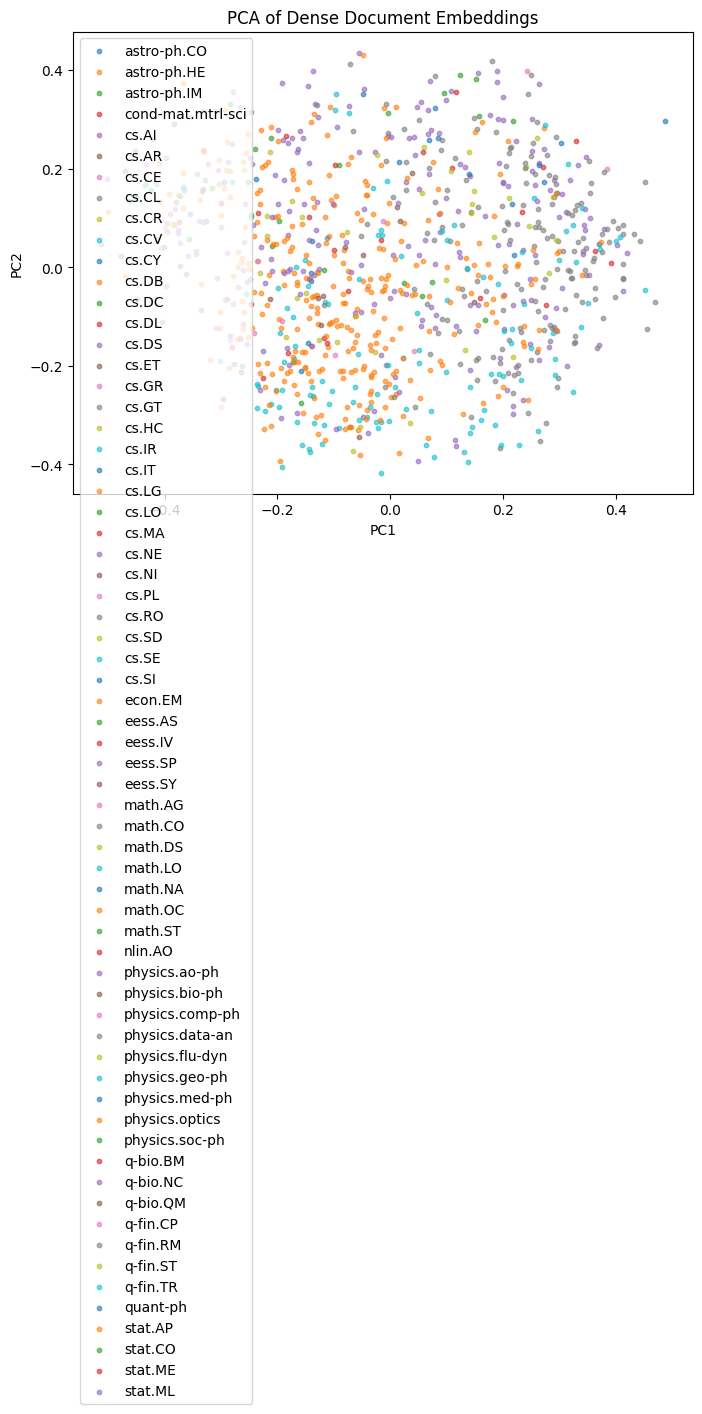

In [55]:
print("Running embedding geometry analysis...")
plot_dense_embedding_geometry(index, papers)